In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

sns.set_style("whitegrid")
%matplotlib inline

In [15]:
data = {
    'MonthlyCharge': [50, 80, 70, 40, 90, 60, 100, 85, 45, 75],
    'ContractLength': [12, 6, 24, 12, 3, 18, 24, 6, 12, 18],
    'Age': [30, 25, 40, 35, 28, 50, 45, 32, 29, 55],
    'Churn': [0, 1, 0, 0, 1, 0, 0, 1, 0, 0]  # 0 = No Churn, 1 = Churn
}

df = pd.DataFrame(data)
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   MonthlyCharge   10 non-null     int64
 1   ContractLength  10 non-null     int64
 2   Age             10 non-null     int64
 3   Churn           10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


,MonthlyCharge,ContractLength,Age,Churn
count,10.000000,10.000000,10.000000,10.000000
mean,69.500000,13.500000,36.900000,0.300000
std,20.200385,7.382412,10.181137,0.483046
min,40.000000,3.000000,25.000000,0.000000
25%,52.500000,7.500000,29.250000,0.000000
50%,72.500000,12.000000,33.500000,0.000000
75%,83.750000,18.000000,43.750000,0.750000
max,100.000000,24.000000,55.000000,1.000000


In [16]:
print("Class balance (Churn):")
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(2), "(proportions)")

Class balance (Churn):
Churn
0    7
1    3
Name: count, dtype: int64

Churn
0    0.7
1    0.3
Name: proportion, dtype: float64 (proportions)


C:\Users\bunga hill\AppData\Local\Temp\ipykernel_8976\862938211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=axes[0], palette=['#4C72B0', '#DD8452'])
C:\Users\bunga hill\AppData\Local\Temp\ipykernel_8976\862938211.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])


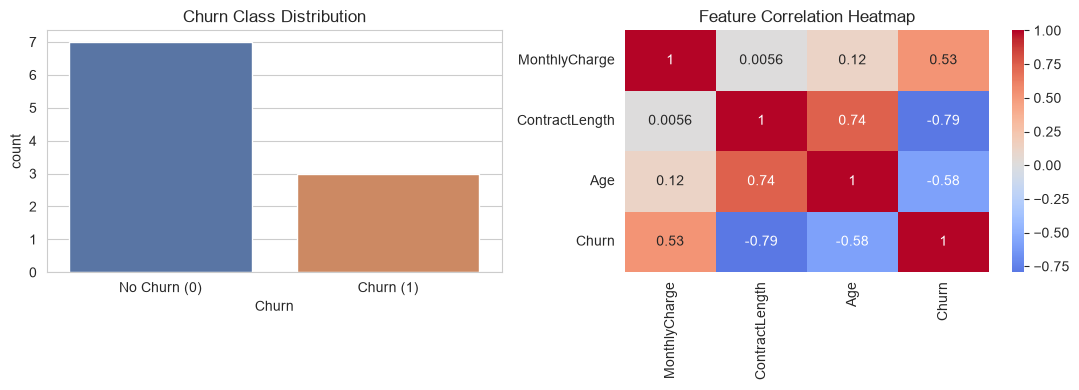

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Class distribution
sns.countplot(x='Churn', data=df, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Churn Class Distribution')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [18]:
X = df[['MonthlyCharge', 'ContractLength', 'Age']]
y = df['Churn']

X.head()

,MonthlyCharge,ContractLength,Age
0,50,12,30
1,80,6,25
2,70,24,40
3,40,12,35
4,90,3,28


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print()
print("y_train:", y_train.tolist())
print("y_test :", y_test.tolist())

Training set size: (7, 3)
Test set size: (3, 3)

y_train: [0, 1, 0, 0, 1, 0, 0]
y_test : [0, 1, 0]


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-1.14431766, -0.28038608, -0.88571536],
       [ 0.60791876, -1.06546709, -0.66026054],
       [-0.14303971,  1.28977595,  0.24155873],
       [ 0.10727978,  0.50469494,  1.93246988],
       [ 0.85823825, -1.4580076 , -1.11117018],
       [-1.64495664, -0.28038608, -0.32207831],
       [ 1.35887723,  1.28977595,  0.80519578]])

In [21]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Model coefficients: [[ 0.69083974 -0.91682156 -0.51786006]]
Model intercept: [-1.24165448]


In [22]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (Churn)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Churn Probability': y_proba.round(3)
}, index=y_test.index)

results

,Actual,Predicted,Churn Probability
8,0,0,0.193
1,1,1,0.675
5,0,0,0.054


In [23]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f} ({acc*100:.0f}%)")

Accuracy: 1.00 (100%)


Confusion Matrix:
 [[2 0]
 [0 1]]


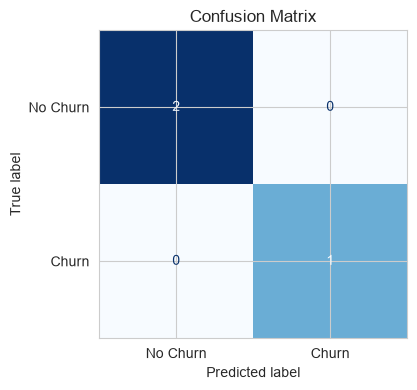

In [24]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Confusion Matrix')
plt.show()

In [25]:
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'], zero_division=0))

              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00         2
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [26]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")

Precision: 1.00
Recall:    1.00
F1 Score:  1.00
